### EDA - Electricity Demand Zurich

Exploratory analysis of hourly data from Zurich (2022-2025).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)
df['year'] = df.index.year

print(f'Shape: {df.shape}')
df.head(3)

Shape: (35045, 20)


,demand,T,Hr,StrGlo,RainDur,WVv,p,hour,dayofweek,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos,demand_log,is_peak,peak_hours_per_day,year
datetime_utc,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,60787.89700,6.78,83.34,0.02,0.0,0.90,977.07,1,5,1,1,winter,0.258819,0.965926,0.5,0.866025,11.015146,0,0,2022
2022-01-01 01:00:00+00:00,59943.68675,6.42,84.66,0.03,0.0,0.70,977.14,2,5,1,1,winter,0.500000,0.866025,0.5,0.866025,11.001161,0,0,2022
2022-01-01 02:00:00+00:00,57751.22200,6.15,84.61,0.02,0.0,0.49,977.38,3,5,1,1,winter,0.707107,0.707107,0.5,0.866025,10.963900,0,0,2022


#### 1. Demand Distribution

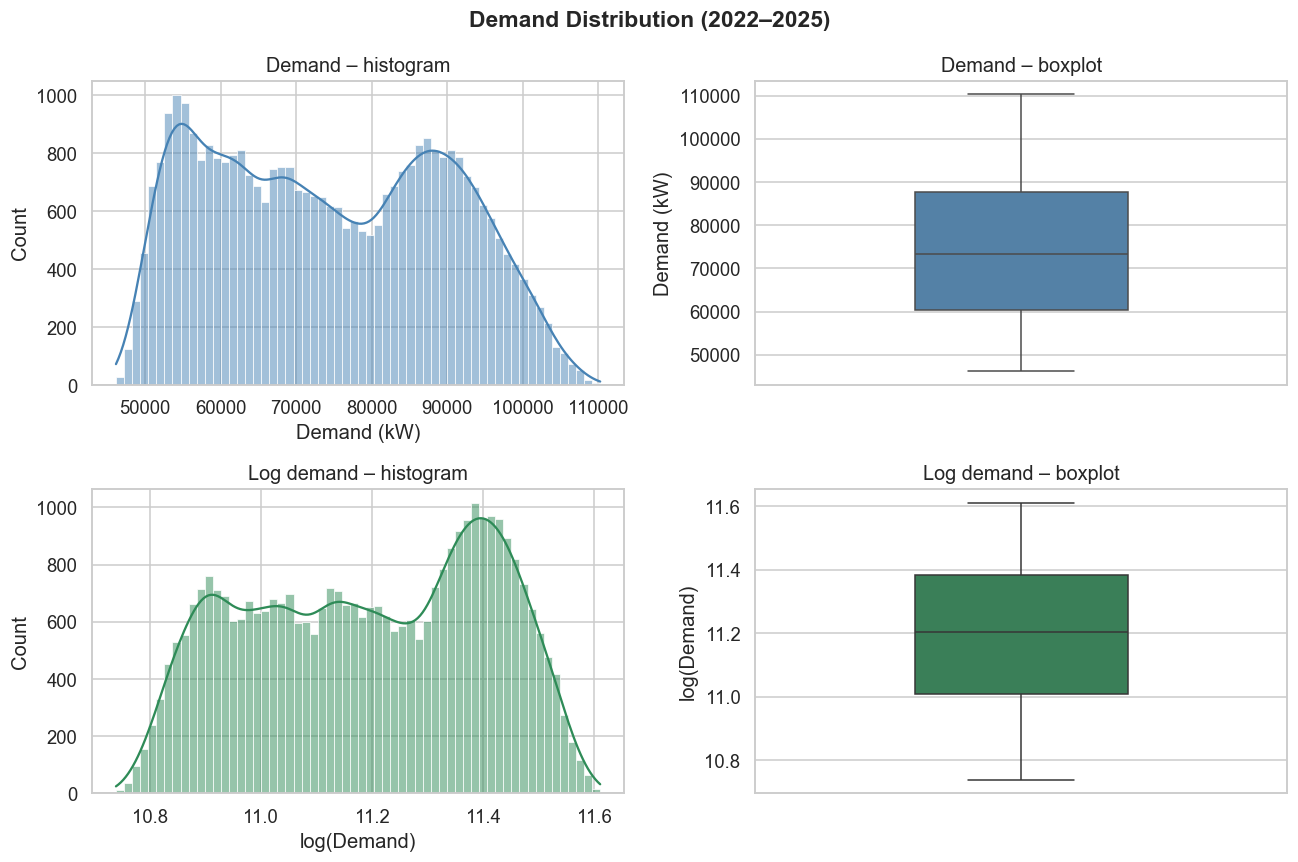

In [2]:
import os
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['demand'], bins=60, ax=axes[0, 0], kde=True, color='steelblue')
axes[0, 0].set_title('Demand – histogram')
axes[0, 0].set_xlabel('Demand (kW)')

sns.boxplot(y=df['demand'], ax=axes[0, 1], color='steelblue', width=0.4)
axes[0, 1].set_title('Demand – boxplot')
axes[0, 1].set_ylabel('Demand (kW)')

sns.histplot(df['demand_log'], bins=60, ax=axes[1, 0], kde=True, color='seagreen')
axes[1, 0].set_title('Log demand – histogram')
axes[1, 0].set_xlabel('log(Demand)')

sns.boxplot(y=df['demand_log'], ax=axes[1, 1], color='seagreen', width=0.4)
axes[1, 1].set_title('Log demand – boxplot')
axes[1, 1].set_ylabel('log(Demand)')

fig.suptitle('Demand Distribution (2022–2025)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_01_demand_distribution.png', bbox_inches='tight')
plt.show()

os.makedirs('../outputs/figures/01_eda', exist_ok=True)

#### 2. Time Series by Year

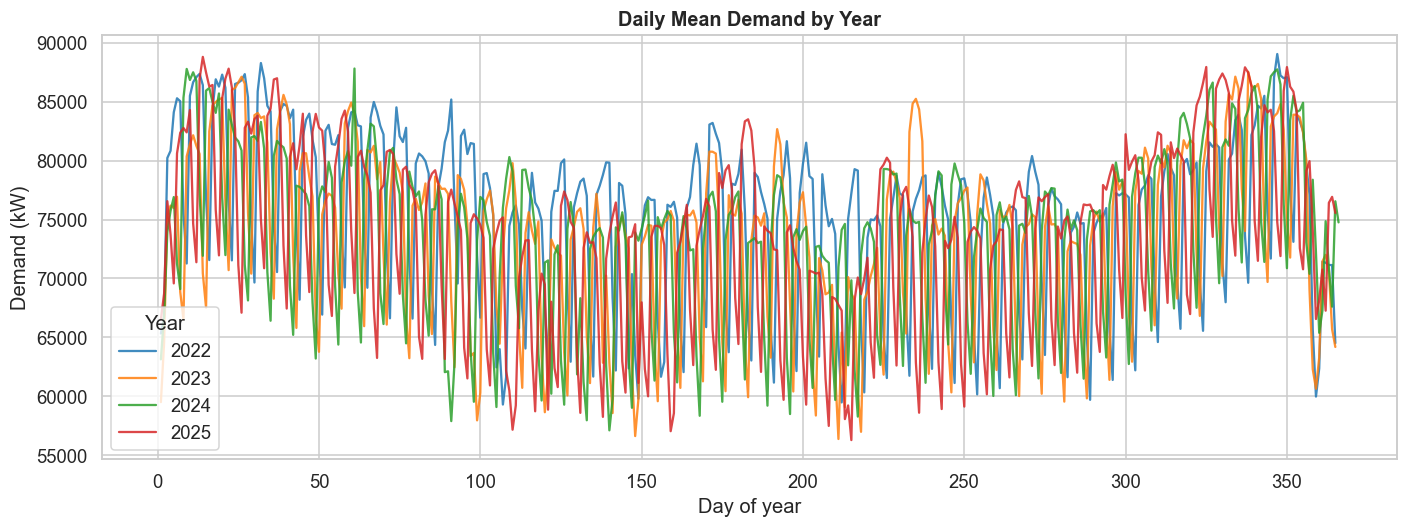

In [3]:
daily = df['demand'].resample('D').mean().rename('demand').reset_index()
daily['year'] = daily['datetime_utc'].dt.year
daily['doy']  = daily['datetime_utc'].dt.dayofyear

fig, ax = plt.subplots(figsize=(13, 5))
for year, grp in daily.groupby('year'):
    ax.plot(grp['doy'], grp['demand'], lw=1.5, label=str(year), alpha=0.85)

ax.set_xlabel('Day of year')
ax.set_ylabel('Demand (kW)')
ax.set_title('Daily Mean Demand by Year', fontweight='bold')
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_02_timeseries_by_year.png', bbox_inches='tight')
plt.show()

#### 3. Temporal Patterns

C:\Users\paula\AppData\Local\Temp\ipykernel_9124\3985825615.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels(day_labels)


C:\Users\paula\AppData\Local\Temp\ipykernel_9124\3985825615.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='season', y='demand', order=season_order,


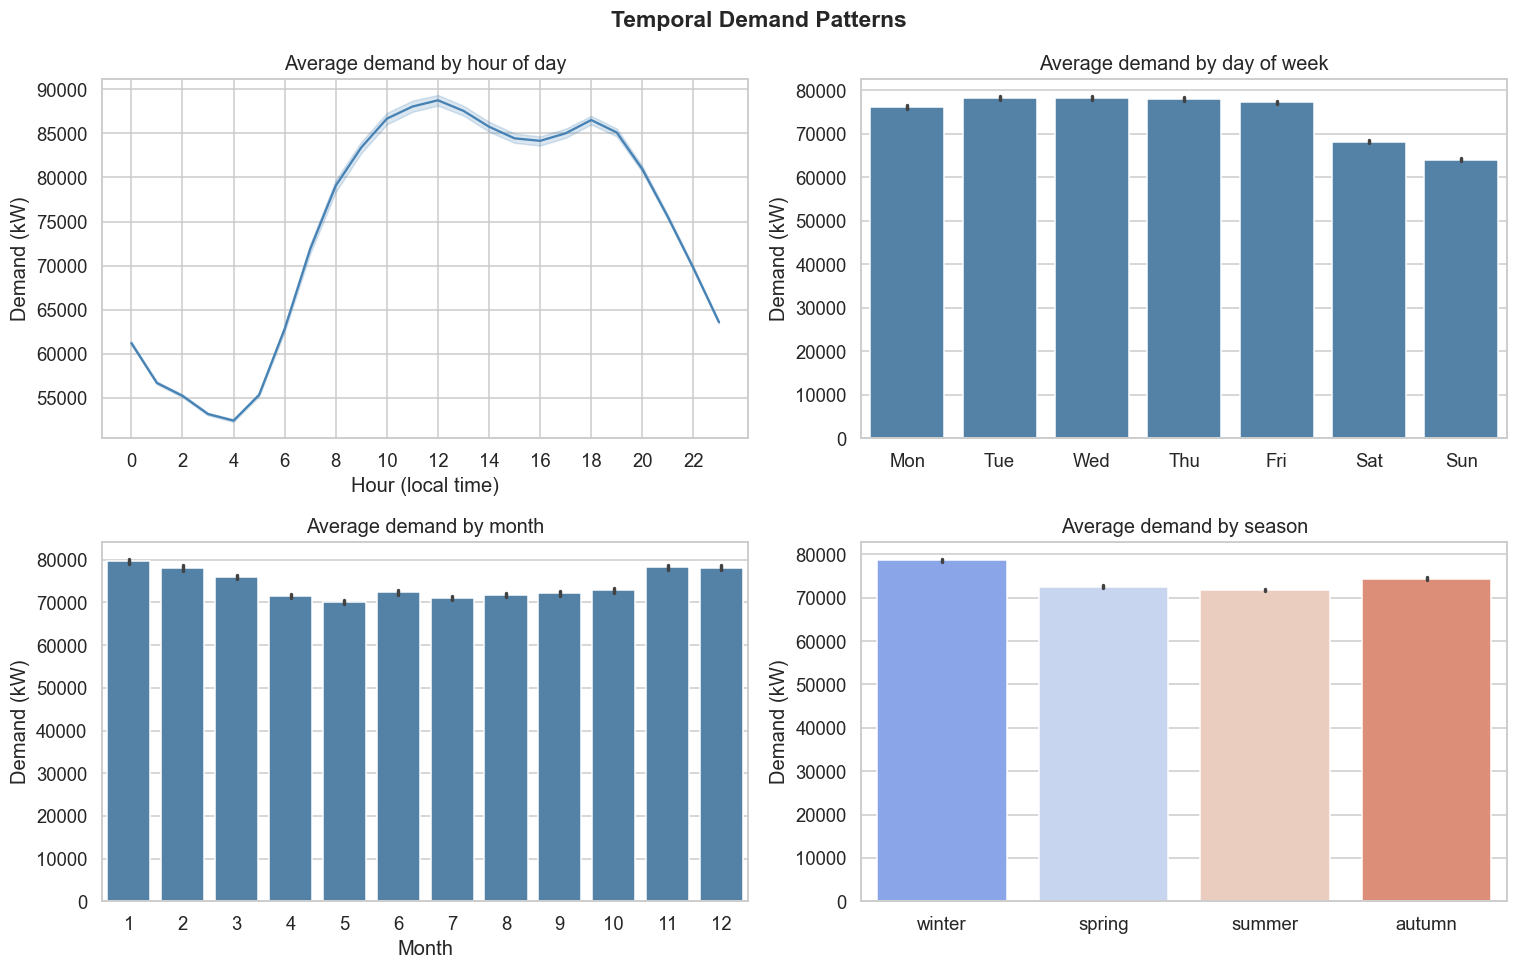

In [4]:
season_order = ['winter', 'spring', 'summer', 'autumn']
day_labels   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# by hour
sns.lineplot(data=df, x='hour', y='demand', ax=axes[0, 0], errorbar='ci', color='steelblue')
axes[0, 0].set_title('Average demand by hour of day')
axes[0, 0].set_xlabel('Hour (local time)')
axes[0, 0].set_ylabel('Demand (kW)')
axes[0, 0].set_xticks(range(0, 24, 2))

# by day of week
sns.barplot(data=df, x='dayofweek', y='demand', ax=axes[0, 1], errorbar='ci', color='steelblue')
axes[0, 1].set_xticklabels(day_labels)
axes[0, 1].set_title('Average demand by day of week')
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('Demand (kW)')

# by month
sns.barplot(data=df, x='month', y='demand', ax=axes[1, 0], errorbar='ci', color='steelblue')
axes[1, 0].set_title('Average demand by month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Demand (kW)')

# by season
sns.barplot(data=df, x='season', y='demand', order=season_order,
            ax=axes[1, 1], errorbar='ci', palette='coolwarm')
axes[1, 1].set_title('Average demand by season')
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('Demand (kW)')

fig.suptitle('Temporal Demand Patterns', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_03_temporal_patterns.png', bbox_inches='tight')
plt.show()

#### 4. Demand vs Weather

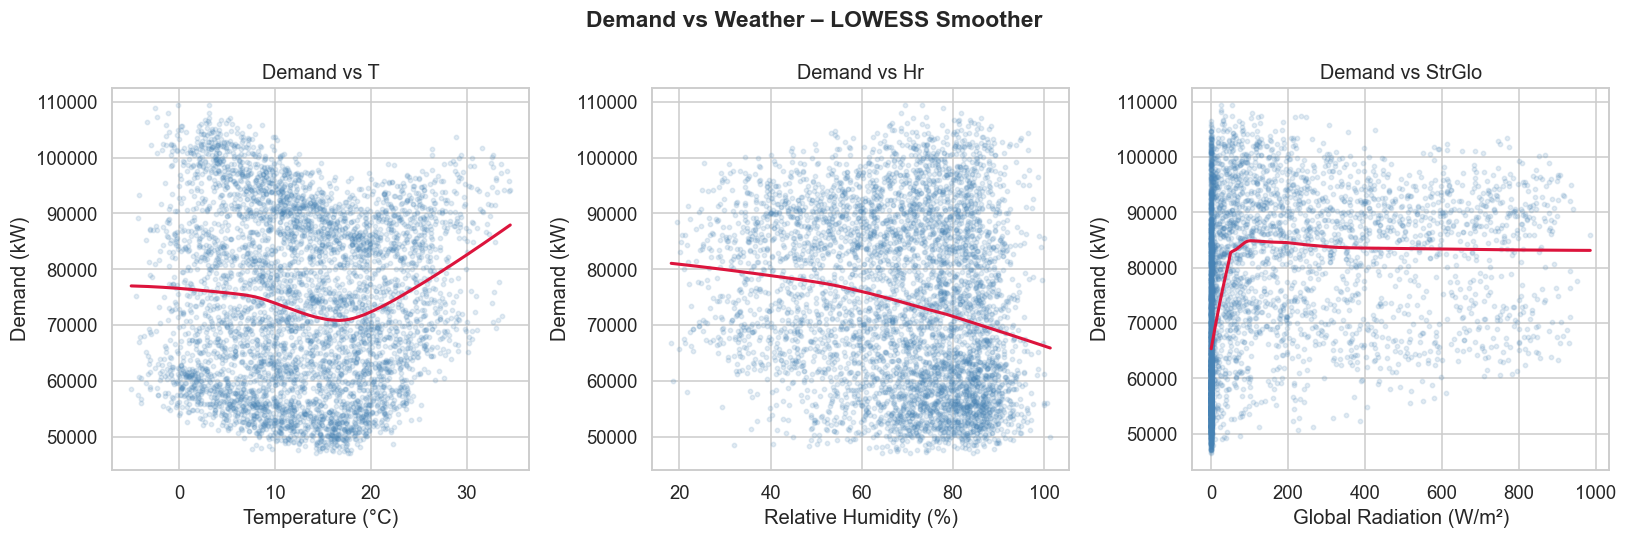

In [5]:
weather_vars = {
    'T':      'Temperature (°C)',
    'Hr':     'Relative Humidity (%)',
    'StrGlo': 'Global Radiation (W/m²)',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, label) in zip(axes, weather_vars.items()):
    sample = df[['demand', col]].dropna().sample(5000, random_state=42)
    sns.regplot(data=sample, x=col, y='demand', ax=ax,
                scatter_kws={'alpha': 0.15, 's': 8, 'color': 'steelblue'},
                lowess=True,
                line_kws={'color': 'crimson', 'lw': 2})
    ax.set_xlabel(label)
    ax.set_ylabel('Demand (kW)')
    ax.set_title(f'Demand vs {col}')

fig.suptitle('Demand vs Weather – LOWESS Smoother', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_04_demand_vs_weather.png', bbox_inches='tight')
plt.show()

#### 5. Correlation Heatmap

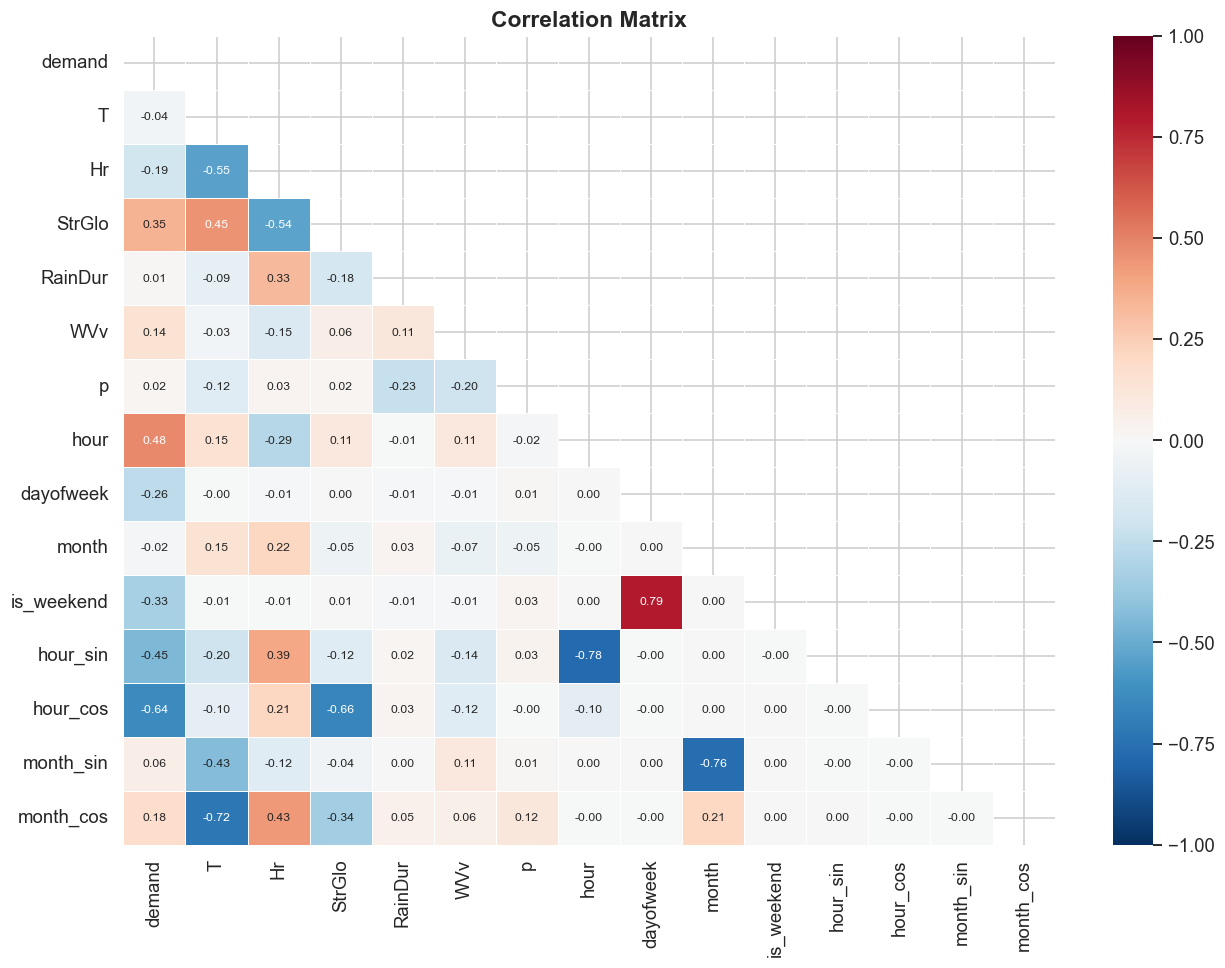

In [6]:
corr_cols = ['demand', 'T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p',
             'hour', 'dayofweek', 'month', 'is_weekend',
             'hour_sin', 'hour_cos', 'month_sin', 'month_cos']

corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

#### 6. Target Variables

C:\Users\paula\AppData\Local\Temp\ipykernel_9124\1208778915.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=peak_by_season, x='season', y='prop_peak',


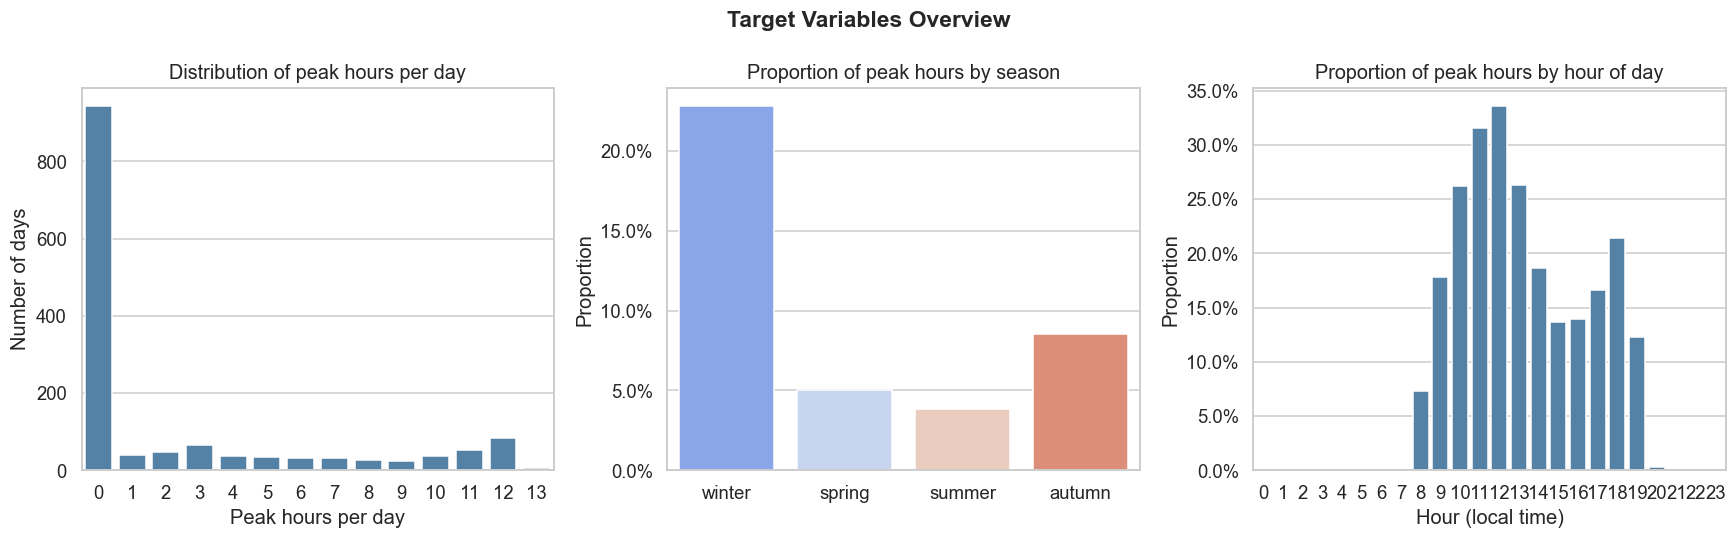

In [7]:
# one value per day for peak_hours_per_day
daily_peaks = df['peak_hours_per_day'].resample('D').first()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# distribution of peak hours per day
vc = daily_peaks.value_counts().sort_index().reset_index()
vc.columns = ['peak_hours', 'count']
sns.barplot(data=vc, x='peak_hours', y='count', ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of peak hours per day')
axes[0].set_xlabel('Peak hours per day')
axes[0].set_ylabel('Number of days')

# is_peak proportion by season
peak_by_season = (df.groupby('season')['is_peak']
                  .mean()
                  .reindex(['winter', 'spring', 'summer', 'autumn'])
                  .reset_index())
peak_by_season.columns = ['season', 'prop_peak']
sns.barplot(data=peak_by_season, x='season', y='prop_peak',
            ax=axes[1], palette='coolwarm')
axes[1].set_title('Proportion of peak hours by season')
axes[1].set_xlabel('')
axes[1].set_ylabel('Proportion')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

# is_peak proportion by hour
peak_by_hour = df.groupby('hour')['is_peak'].mean().reset_index()
peak_by_hour.columns = ['hour', 'prop_peak']
sns.barplot(data=peak_by_hour, x='hour', y='prop_peak',
            ax=axes[2], color='steelblue')
axes[2].set_title('Proportion of peak hours by hour of day')
axes[2].set_xlabel('Hour (local time)')
axes[2].set_ylabel('Proportion')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

fig.suptitle('Target Variables Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/01_eda/01_06_targets.png', bbox_inches='tight')
plt.show()

#### 7. NE5 vs NE7

NE5 and NE7 were merged into demand during preprocessing, so this is skipped.

In [8]:
# NE5 and NE7 are not in the processed dataset – they were merged into 'demand'.
# To compare them load the raw EWZ file directly.
print('Skipped – NE5 / NE7 not available in hourly_merged.csv.')

Skipped – NE5 / NE7 not available in hourly_merged.csv.
